# MSc Business Analytics Dissertation

## Time-Series Forecasting of UK Clothing Retail Sales Using SARIMAX

### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

plt.style.use('ggplot')

## 2. Load the Dataset
This section imports the final master dataset used for the time-series analysis.

In [2]:
df = pd.read_excel("Master dataset.xlsx")

df.head()

,Date,Sales_volume,Clothing_CPI,Winter_Coats,Summer_Dresses,Black_Friday_Clothing,School_Uniform
0,2015 JAN,82.7,98.0,7,7,0,16
1,2015 FEB,79.5,99.3,4,9,0,14
2,2015 MAR,87.2,99.2,2,11,0,19
3,2015 APR,93.4,99.9,1,15,0,22
4,2015 MAY,94.3,100.5,1,13,0,18


## 3. Data Understanding

This section checks the size, structure, data types and missing values in the dataset.

In [3]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (132, 7)

Column names:
Index(['Date', 'Sales_volume', 'Clothing_CPI', 'Winter_Coats',
       'Summer_Dresses', 'Black_Friday_Clothing', 'School_Uniform'],
      dtype='str')

Data types:
Date                         str
Sales_volume             float64
Clothing_CPI             float64
Winter_Coats               int64
Summer_Dresses             int64
Black_Friday_Clothing      int64
School_Uniform             int64
dtype: object

Missing values:
Date                     0
Sales_volume             0
Clothing_CPI             0
Winter_Coats             0
Summer_Dresses           0
Black_Friday_Clothing    0
School_Uniform           0
dtype: int64


## 4. Data Pre-processing

The Date column is converted into a datetime format and set as the index to prepare the dataset for time-series analysis.

In [4]:
df['Date'] = pd.to_datetime(df['Date'], format='%Y %b')

df.set_index('Date', inplace=True)

df.head()

,Sales_volume,Clothing_CPI,Winter_Coats,Summer_Dresses,Black_Friday_Clothing,School_Uniform
Date,,,,,,
2015-01-01,82.7,98.0,7,7,0,16
2015-02-01,79.5,99.3,4,9,0,14
2015-03-01,87.2,99.2,2,11,0,19
2015-04-01,93.4,99.9,1,15,0,22
2015-05-01,94.3,100.5,1,13,0,18


In [5]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 132 entries, 2015-01-01 to 2025-12-01
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Sales_volume           132 non-null    float64
 1   Clothing_CPI           132 non-null    float64
 2   Winter_Coats           132 non-null    int64  
 3   Summer_Dresses         132 non-null    int64  
 4   Black_Friday_Clothing  132 non-null    int64  
 5   School_Uniform         132 non-null    int64  
dtypes: float64(2), int64(4)
memory usage: 7.2 KB


In [6]:
# Split the dataset into training and test periods
# Training data: January 2015 - December 2024
# Test data: January 2025 - December 2025

train = df.loc[:'2024-12-01'].copy()
test = df.loc['2025-01-01':'2025-12-01'].copy()

print("Training period:", train.index.min(), "to", train.index.max())
print("Training observations:", len(train))

print("\nTest period:", test.index.min(), "to", test.index.max())
print("Test observations:", len(test))

Training period: 2015-01-01 00:00:00 to 2024-12-01 00:00:00
Training observations: 120

Test period: 2025-01-01 00:00:00 to 2025-12-01 00:00:00
Test observations: 12


## 5. Exploratory Data Analysis (EDA)

This section explores the characteristics of the dataset using descriptive statistics, correlation analysis and visualisations. The objective is to understand the behaviour of the variables before developing forecasting models.

### 5.1 Descriptive Statistics

In [7]:
# Descriptive statistics for the training period only (2015-2024)
descriptive_stats = train.describe().round(2)

descriptive_stats

,Sales_volume,Clothing_CPI,Winter_Coats,Summer_Dresses,Black_Friday_Clothing,School_Uniform
count,120.00,120.00,120.00,120.00,120.00,120.00
mean,95.58,105.60,9.29,14.39,0.63,30.19
std,18.82,7.13,8.54,11.65,2.08,20.03
min,31.10,95.70,1.00,2.00,0.00,9.00
25%,87.15,100.57,2.00,4.00,0.00,17.75
50%,95.70,102.95,6.50,11.00,0.00,21.00
75%,101.55,108.62,16.00,20.00,0.00,39.25
max,144.70,122.60,33.00,53.00,9.00,100.00


### Interpretation

The descriptive statistics summarise the characteristics of the 2015–2024 training dataset. The Sales Volume Index recorded a mean of 95.58 and a standard deviation of 18.82, indicating substantial variation over the study period. Values ranged from 31.10 to 144.70, reflecting both pronounced seasonal fluctuations and exceptional disruption during the COVID-19 period. Clothing CPI displayed comparatively lower variability, with a mean of 105.60 and a standard deviation of 7.13. The Google Trends indicators showed differing levels of variation, with School Uniform recording the highest maximum search-interest value of 100. These descriptive results demonstrate that the variables exhibit different scales and temporal characteristics, supporting further time-series and relationship analysis.

### 5.2 Correlation Analysis

Correlation analysis is conducted to examine the linear relationships between retail sales and the selected explanatory variables before forecasting.

In [8]:
# Correlation analysis using training data only (2015-2024)
correlation_matrix = train.corr().round(2)

correlation_matrix

,Sales_volume,Clothing_CPI,Winter_Coats,Summer_Dresses,Black_Friday_Clothing,School_Uniform
Sales_volume,1.00,0.27,0.35,-0.18,0.24,-0.00
Clothing_CPI,0.27,1.00,0.11,0.02,0.12,-0.05
Winter_Coats,0.35,0.11,1.00,-0.70,0.51,-0.09
Summer_Dresses,-0.18,0.02,-0.70,1.00,-0.30,0.19
Black_Friday_Clothing,0.24,0.12,0.51,-0.30,1.00,-0.20
School_Uniform,-0.00,-0.05,-0.09,0.19,-0.20,1.00


In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd

# Explanatory variables from training data only
X_vif = train[
    [
        'Clothing_CPI',
        'Winter_Coats',
        'Summer_Dresses',
        'Black_Friday_Clothing',
        'School_Uniform'
    ]
].copy()

# Add constant for correct VIF calculation
X_vif_const = add_constant(X_vif)

vif_table = pd.DataFrame()
vif_table['Variable'] = X_vif_const.columns
vif_table['VIF'] = [
    variance_inflation_factor(X_vif_const.values, i)
    for i in range(X_vif_const.shape[1])
]

# Remove constant from displayed results
vif_table = vif_table[vif_table['Variable'] != 'const']

vif_table.round(2)

,Variable,VIF
1,Clothing_CPI,1.04
2,Winter_Coats,2.54
3,Summer_Dresses,2.11
4,Black_Friday_Clothing,1.42
5,School_Uniform,1.09


### 5.3 Correlation Heatmap

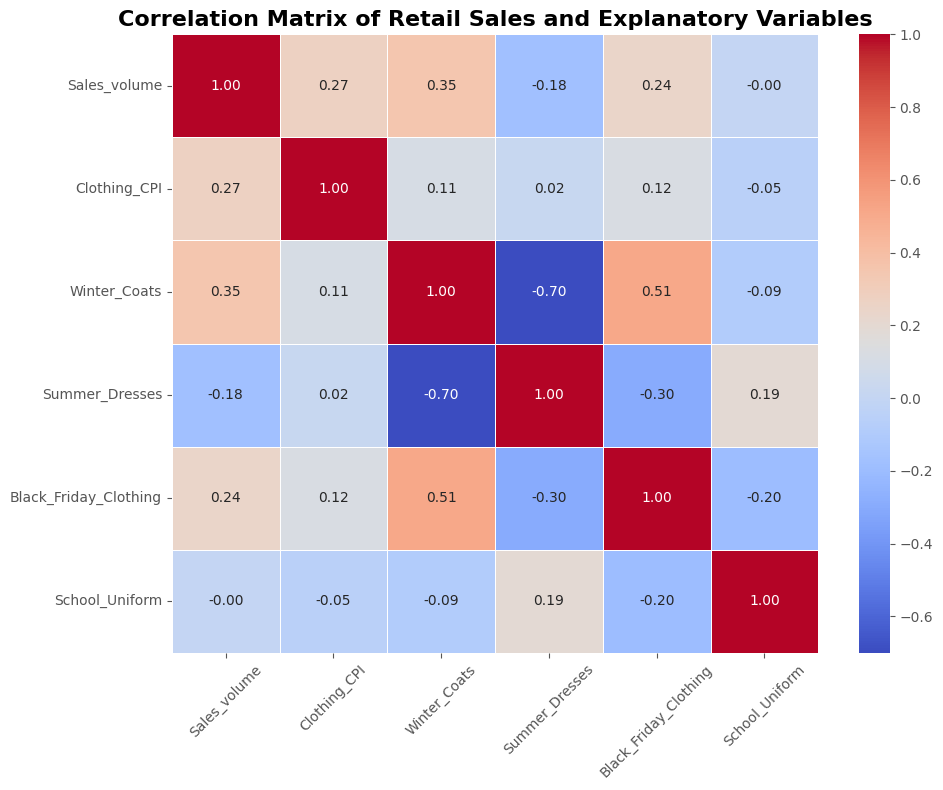

In [10]:
# Create the correlation heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title(
    "Correlation Matrix of Retail Sales and Explanatory Variables",
    fontsize=16,
    fontweight='bold'
)

plt.xticks(rotation=45)

plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig("Correlation_Heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

### Interpretation

The correlation heatmap shows the relationships between retail sales volume and the explanatory variables during the 2015–2024 training period. Sales volume has a moderate positive correlation with Winter Coats search interest (r = 0.35), while weaker positive relationships are observed with Clothing CPI (r = 0.27) and Black Friday Clothing (r = 0.24). Summer Dresses shows a weak negative relationship with sales volume (r = −0.18), while School Uniform has almost no contemporaneous linear relationship with sales volume.

A relatively strong negative correlation is observed between Winter Coats and Summer Dresses (r = −0.70), while Winter Coats and Black Friday Clothing are moderately positively correlated (r = 0.51). However, the subsequent VIF analysis produced values below 3 for all explanatory variables, indicating that severe multicollinearity is not evident. Importantly, these correlations describe contemporaneous linear relationships only and do not by themselves determine whether the variables provide useful forecasting information.

## 6. Time Series Analysis

This section explores the temporal behaviour of UK clothing retail sales and the explanatory variables. Time-series visualisations are used to identify trends, seasonality and unusual observations before statistical forecasting models are developed.

### 6.1 Retail Sales Time Series

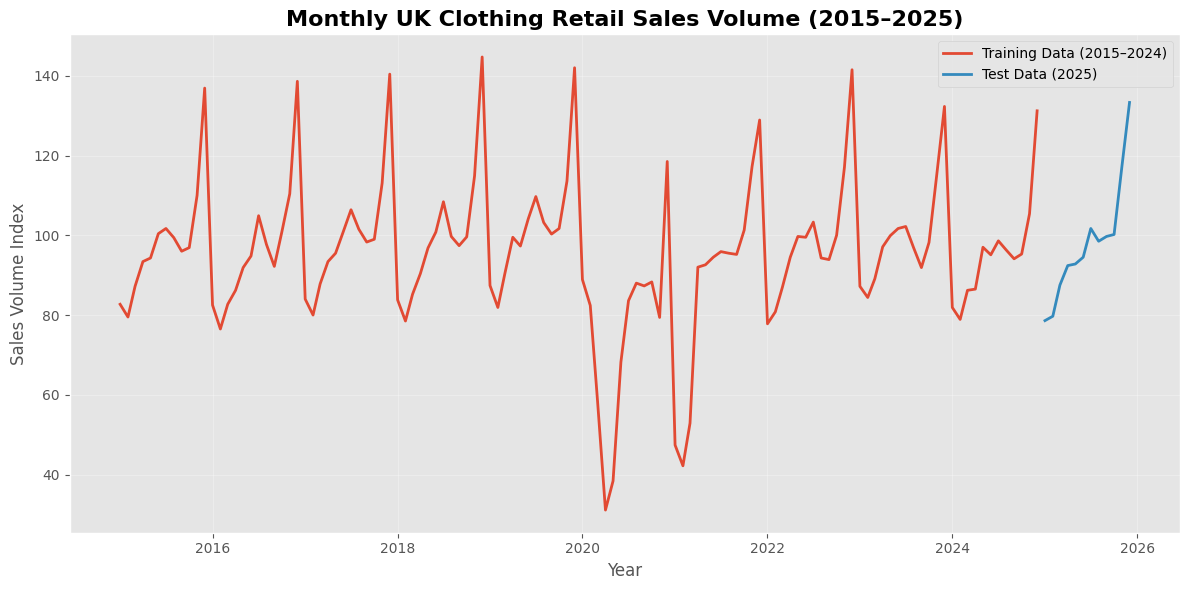

In [11]:
plt.figure(figsize=(12,6))

# Training period
plt.plot(
    train.index,
    train['Sales_volume'],
    label='Training Data (2015–2024)',
    linewidth=2
)

# Held-out test period
plt.plot(
    test.index,
    test['Sales_volume'],
    label='Test Data (2025)',
    linewidth=2
)

plt.title(
    "Monthly UK Clothing Retail Sales Volume (2015–2025)",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Year")
plt.ylabel("Sales Volume Index")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("Figure_1_Sales_Volume_NSA.png", dpi=300)

plt.show()

### Interpretation

The non-seasonally adjusted retail sales volume series displays a clear recurring annual pattern, with pronounced peaks towards the end of each year and lower sales levels during other months. This provides visual evidence of seasonality in UK clothing retail sales and supports the use of seasonal forecasting methods. A substantial disruption is also visible during 2020 and 2021, corresponding to the COVID-19 period, when sales fell sharply before recovering. From 2022 onwards, the recurring seasonal pattern becomes more evident again. The 2025 observations are shown separately as the held-out test period and were not used for model development or selection.

### 6.2 Clothing CPI Time Series

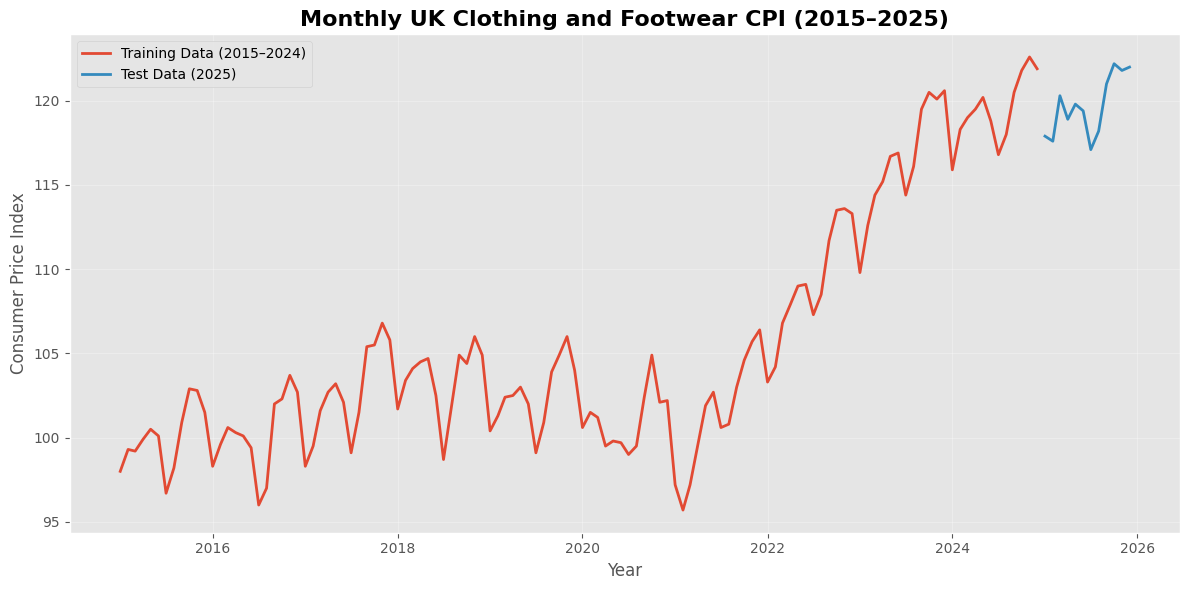

In [12]:
plt.figure(figsize=(12,6))

# Training period
plt.plot(
    train.index,
    train['Clothing_CPI'],
    label='Training Data (2015–2024)',
    linewidth=2
)

# Held-out test period
plt.plot(
    test.index,
    test['Clothing_CPI'],
    label='Test Data (2025)',
    linewidth=2
)

plt.title(
    "Monthly UK Clothing and Footwear CPI (2015–2025)",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Year")
plt.ylabel("Consumer Price Index")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("Figure_2_CPI.png", dpi=300)

plt.show()

### Interpretation

The Clothing and Footwear CPI shows an overall upward movement in the price level across the study period, although monthly fluctuations are evident. The index remains comparatively stable during much of 2015–2020 before declining temporarily around 2020–2021 and subsequently increasing more strongly from 2021 onwards. This indicates a substantial rise in clothing and footwear price levels during the later part of the training period. The 2025 observations are displayed separately as the held-out test period and were not used for model development or selection.

### 6.3 Google Trends Time Series

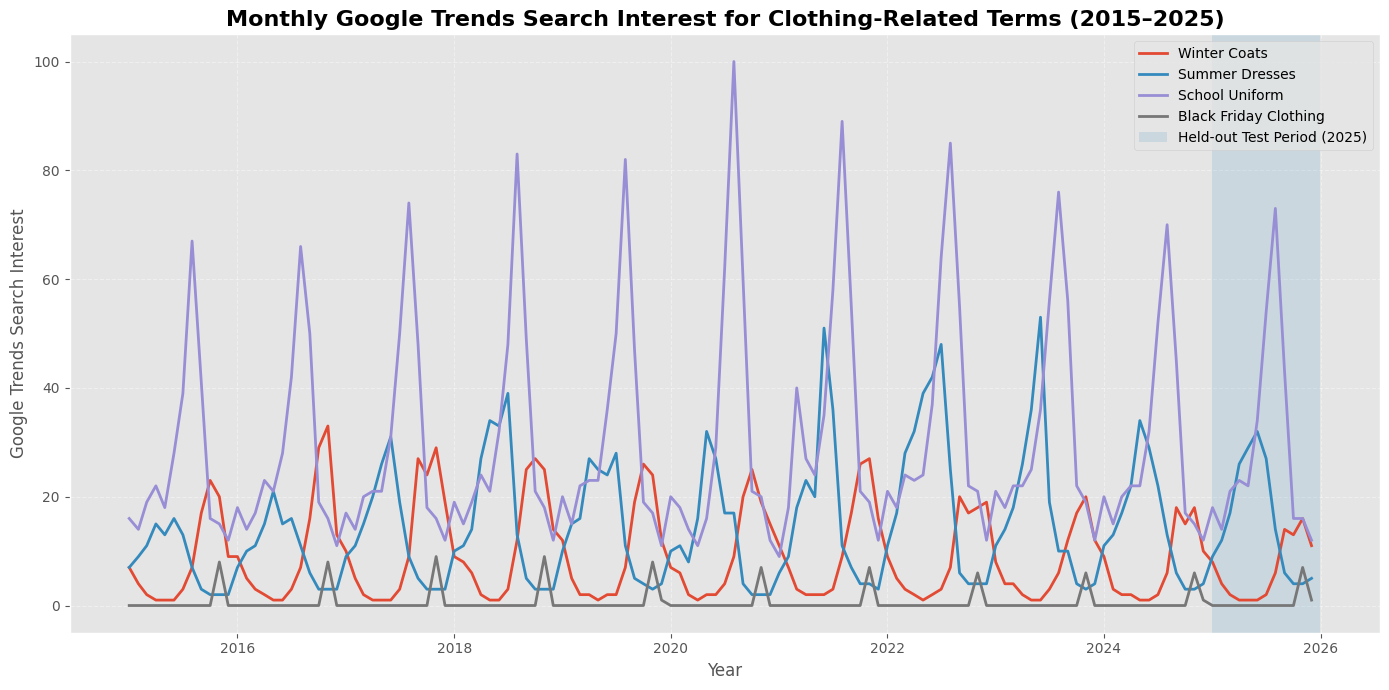

In [13]:
# ====================================================
# Figure 3: Google Trends Search Interest (2015–2025)
# 2025 is shown as the held-out test period
# ====================================================

plt.figure(figsize=(14, 7))

plt.plot(
    df.index,
    df['Winter_Coats'],
    label='Winter Coats',
    linewidth=2
)

plt.plot(
    df.index,
    df['Summer_Dresses'],
    label='Summer Dresses',
    linewidth=2
)

plt.plot(
    df.index,
    df['School_Uniform'],
    label='School Uniform',
    linewidth=2
)

plt.plot(
    df.index,
    df['Black_Friday_Clothing'],
    label='Black Friday Clothing',
    linewidth=2
)

# Shade the held-out 2025 test period
plt.axvspan(
    pd.Timestamp('2025-01-01'),
    pd.Timestamp('2025-12-31'),
    alpha=0.15,
    label='Held-out Test Period (2025)'
)

plt.title(
    "Monthly Google Trends Search Interest for Clothing-Related Terms (2015–2025)",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Google Trends Search Interest", fontsize=12)

plt.legend(
    loc='upper right',
    fontsize=10,
    frameon=True
)

plt.grid(
    True,
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    "Figure_3_Google_Trends_NSA.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The Google Trends variables exhibit distinct recurring seasonal patterns. Winter Coats and Summer Dresses show contrasting seasonal search behaviour, while School Uniform displays pronounced annual peaks associated with periods of increased search interest. Black Friday Clothing shows highly concentrated annual peaks around the Black Friday period. These patterns demonstrate that the selected search indicators contain substantial temporal and seasonal variation. However, the presence of seasonal search behaviour does not itself establish forecasting value; whether these indicators improve retail sales forecasts is evaluated through the subsequent out-of-sample SARIMAX analysis. The shaded area represents the held-out 2025 test period, which was excluded from model development and selection.

## 7. Time Series Decomposition and Stationarity Testing

This section investigates the statistical properties of the retail sales time series before forecasting models are developed. Seasonal decomposition is used to separate the series into trend, seasonal and residual components. The Augmented Dickey-Fuller (ADF) test is then applied to determine whether the series is stationary. If required, differencing will be performed to achieve stationarity before fitting the SARIMA and SARIMAX models.

### 7.1 Seasonal Decomposition

Seasonal decomposition separates the observed retail sales series into three components:

- Trend
- Seasonal
- Residual (Irregular)

This helps identify long-term movements and repeating seasonal patterns within the data.

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [15]:
decomposition = seasonal_decompose(
    train['Sales_volume'],
    model='additive',
    period=12
)

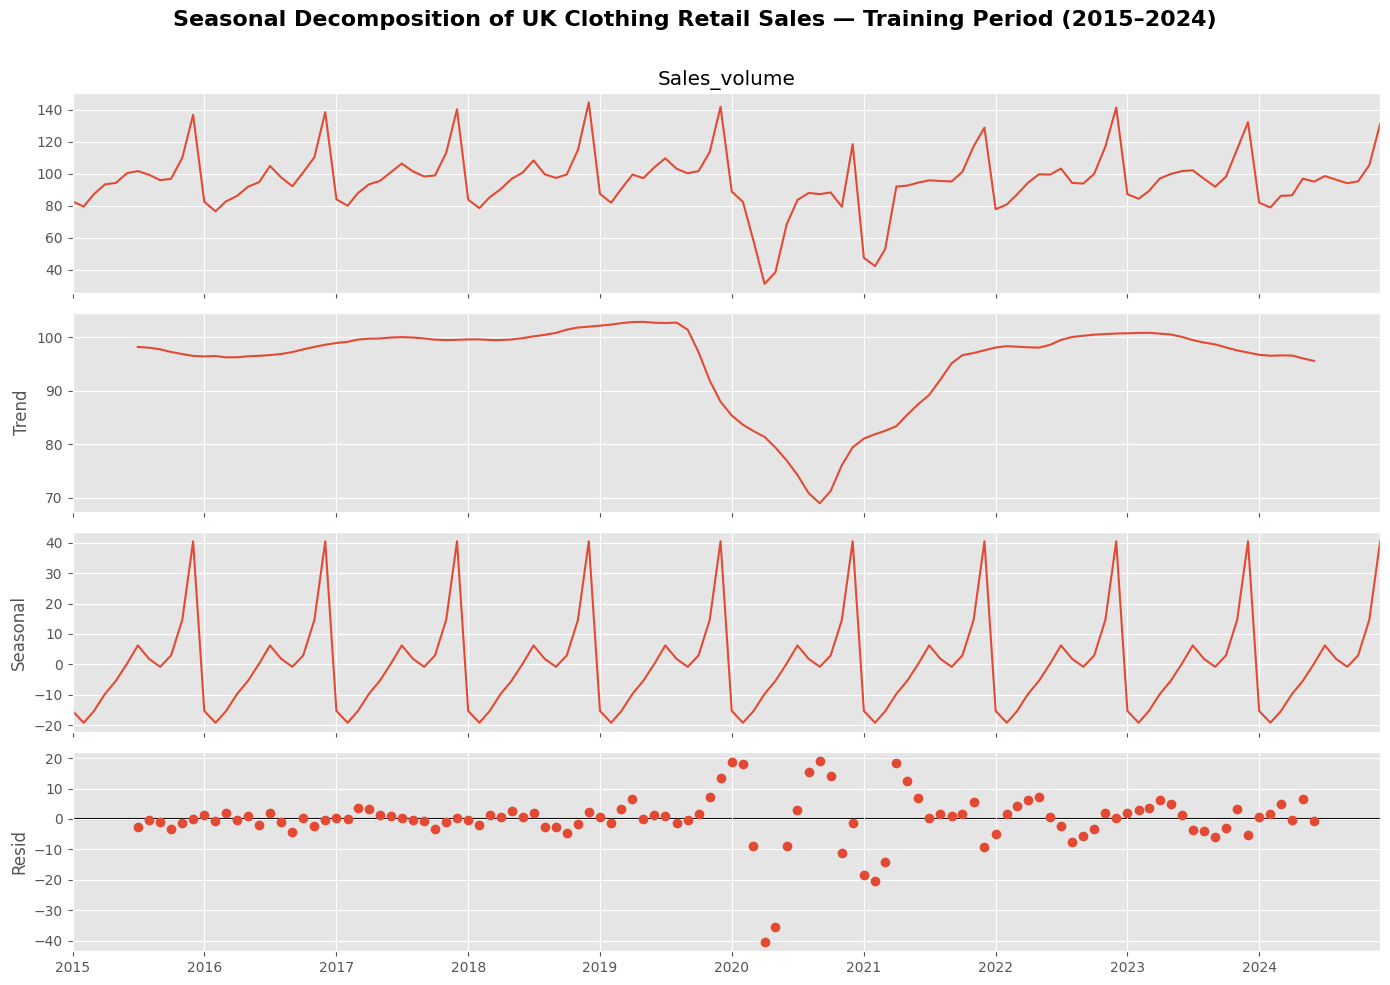

In [16]:
fig = decomposition.plot()

fig.set_size_inches(14, 10)

plt.suptitle(
    "Seasonal Decomposition of UK Clothing Retail Sales — Training Period (2015–2024)",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout(rect=[0,0,1,0.97])

plt.savefig(
    "Figure_4_Seasonal_Decomposition.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The seasonal decomposition of the 2015–2024 training series reveals a pronounced and recurring annual seasonal pattern in UK clothing retail sales. The seasonal component shows a consistent 12-month cycle, including a substantial year-end peak and lower sales levels during other parts of the year. The trend component remains comparatively stable before declining sharply around 2020, followed by a gradual recovery towards pre-disruption levels. The residual component contains particularly large deviations around 2020–2021, which may reflect exceptional disruption during the COVID-19 period, although this explanation is not tested directly. Overall, the decomposition provides empirical support for modelling annual seasonality and therefore supports the consideration of seasonal forecasting approaches such as Seasonal Naïve and SARIMA. Importantly, the decomposition was conducted exclusively on the 2015–2024 training period, with the 2025 test observations excluded.

### 7.2 Augmented Dickey-Fuller (ADF) Test

The Augmented Dickey-Fuller (ADF) test is used to determine whether the retail sales time series is stationary. A stationary time series has constant statistical properties over time and is a key assumption for ARIMA and SARIMA models.

### Hypotheses

- **Null hypothesis (H₀):** The time series is non-stationary (contains a unit root).
- **Alternative hypothesis (H₁):** The time series is stationary.

A p-value less than 0.05 indicates that the null hypothesis can be rejected, suggesting that the series is stationary.

In [17]:
from statsmodels.tsa.stattools import adfuller

In [18]:
# Perform the Augmented Dickey-Fuller Test

adf_result = adfuller(train['Sales_volume'])

print("ADF Statistic :", adf_result[0])
print("p-value       :", adf_result[1])
print("Number of Lags:", adf_result[2])
print("Observations  :", adf_result[3])

print("\nCritical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value:.4f}")

ADF Statistic : -2.01603850227388
p-value       : 0.27958535218895475
Number of Lags: 13
Observations  : 106

Critical Values:
1%: -3.4936
5%: -2.8892
10%: -2.5815


### Interpretation

The Augmented Dickey–Fuller test was conducted using only the 2015–2024 training period. The test produced an ADF statistic of −2.016 and a p-value of 0.280. Since the p-value exceeds the 5% significance level, the null hypothesis of a unit root cannot be rejected. The retail sales series is therefore treated as non-stationary for model-development purposes. This finding indicates that differencing should be considered before estimating the SARIMA and SARIMAX models. Given the clear annual pattern identified in the seasonal decomposition, both non-seasonal and seasonal differencing are examined in the subsequent analysis.

### 7.3 First-Order Differencing

First-order differencing removes long-term trends by calculating the change between consecutive monthly observations. This transformation is commonly used to achieve stationarity before fitting ARIMA-based forecasting models.

In [19]:
# First-order differencing using training data only
sales_diff = train['Sales_volume'].diff().dropna()

sales_diff.head()

Date
2015-02-01   -3.2
2015-03-01    7.7
2015-04-01    6.2
2015-05-01    0.9
2015-06-01    6.1
Name: Sales_volume, dtype: float64

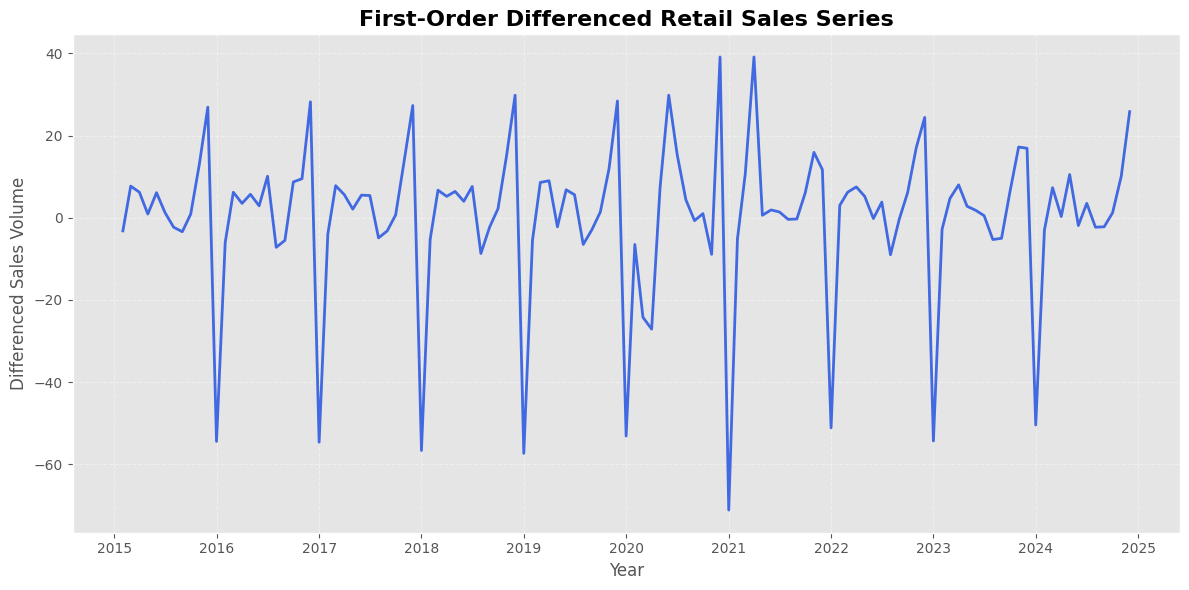

In [20]:
plt.figure(figsize=(12,6))

plt.plot(
    sales_diff,
    color='royalblue',
    linewidth=2
)

plt.title(
    "First-Order Differenced Retail Sales Series",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Year")
plt.ylabel("Differenced Sales Volume")

plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()

plt.savefig(
    "Figure_5_First_Differencing.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [21]:
# ADF test after first-order differencing

adf_diff = adfuller(sales_diff)

print("ADF Statistic :", adf_diff[0])
print("p-value       :", adf_diff[1])
print("Number of Lags:", adf_diff[2])
print("Observations  :", adf_diff[3])

print("\nCritical Values:")
for key, value in adf_diff[4].items():
    print(f"{key}: {value:.4f}")

ADF Statistic : -3.9131822359476938
p-value       : 0.0019399467458152886
Number of Lags: 12
Observations  : 106

Critical Values:
1%: -3.4936
5%: -2.8892
10%: -2.5815


### Interpretation

Following first-order differencing, the ADF test produced a statistic of −3.913 and a p-value of 0.0019. Since the p-value is below the 5% significance level, the null hypothesis of a unit root is rejected. The first-differenced training series is therefore considered stationary according to the ADF test, supporting the use of first-order non-seasonal differencing (d = 1). However, the strong annual seasonal pattern identified in the decomposition indicates that seasonal dynamics should still be investigated separately when specifying the SARIMA model.

### 7.4 Augmented Dickey-Fuller Test After Differencing

The ADF test is repeated on the first-order differenced series to confirm whether stationarity has been achieved.

In [22]:
# Perform ADF Test on the differenced series

adf_diff = adfuller(sales_diff)

print("ADF Statistic :", adf_diff[0])
print("p-value       :", adf_diff[1])
print("Number of Lags:", adf_diff[2])
print("Observations  :", adf_diff[3])

print("\nCritical Values:")

for key, value in adf_diff[4].items():
    print(f"{key}: {value:.4f}")

ADF Statistic : -3.9131822359476938
p-value       : 0.0019399467458152886
Number of Lags: 12
Observations  : 106

Critical Values:
1%: -3.4936
5%: -2.8892
10%: -2.5815


### Interpretation

The Augmented Dickey–Fuller (ADF) test was repeated after applying first-order differencing to the retail sales training series covering January 2015 to December 2024.

The ADF statistic was −3.9132, with a p-value of 0.0019, which is below the 5% significance level. Therefore, the null hypothesis of a unit root is rejected, indicating that the first-order differenced training series is stationary.

These findings indicate that first-order differencing successfully addressed the non-stationarity identified in the original training series. Consequently, a non-seasonal differencing order of d = 1 is considered appropriate for subsequent SARIMA and SARIMAX model development.

### 7.5 Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF)

The ACF and PACF plots are used to examine the autocorrelation structure of the stationary retail sales series. These plots provide guidance when selecting the autoregressive (p) and moving average (q) orders for the SARIMA model.

In [23]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

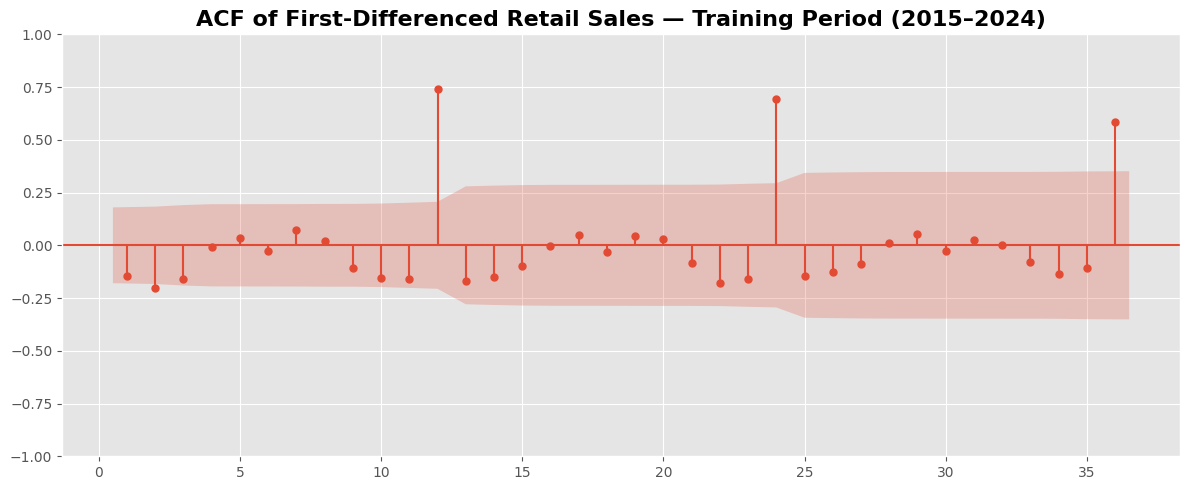

In [24]:
fig, ax = plt.subplots(figsize=(12,5))

plot_acf(
    sales_diff,
    lags=36,
    zero=False,
    ax=ax
)

ax.set_title(
    "ACF of First-Differenced Retail Sales — Training Period (2015–2024)",
    fontsize=16,
    fontweight="bold"

)

plt.tight_layout()

plt.savefig(
    "Figure_6_ACF.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

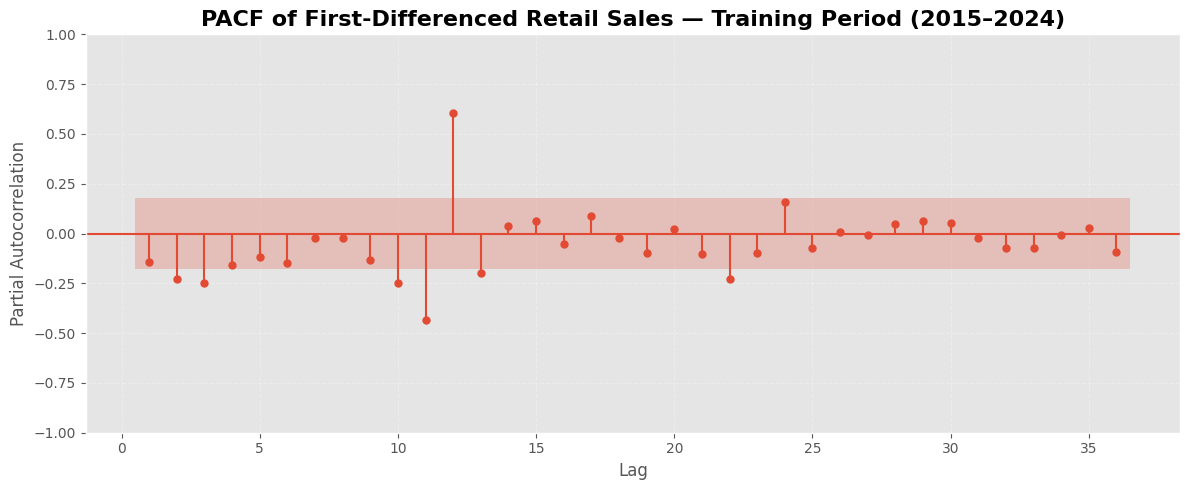

In [25]:
# ====================================================
# PACF of First-Differenced Retail Sales
# Training Period: January 2015 - December 2024
# ====================================================

from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

plot_pacf(
    sales_diff,
    lags=36,
    zero=False,
    method="ywm",
    ax=ax
)

ax.set_title(
    "PACF of First-Differenced Retail Sales — Training Period (2015–2024)",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Lag")
ax.set_ylabel("Partial Autocorrelation")

plt.grid(
    True,
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "Figure_7_PACF_Training.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The ACF and PACF plots were examined using the first-differenced retail sales training series covering January 2015 to December 2024. The ACF shows pronounced positive spikes at seasonal lags 12, 24 and 36, indicating a strong recurring annual pattern in UK clothing retail sales. In particular, the substantial autocorrelation at lag 12 provides clear evidence that observations separated by one year remain strongly related.

The PACF similarly displays a pronounced spike at lag 12, alongside several smaller significant correlations at shorter lags. Together, these results indicate that first-order differencing addresses the non-stationarity of the series but does not remove its annual seasonal dependence.

The persistence of significant autocorrelation at multiples of 12 provides empirical justification for incorporating a 12-month seasonal structure in the subsequent SARIMA and SARIMAX models. The final autoregressive, moving-average and seasonal orders are therefore determined through model comparison and validation rather than from the ACF and PACF plots alone.

## 8. Model Development

This section develops and evaluates forecasting models for UK clothing retail sales using the non-seasonally adjusted sales volume series. All model development and selection are conducted exclusively using the January 2015–December 2024 training period. The January–December 2025 observations are retained as a completely held-out test set and are used only for final out-of-sample evaluation. Candidate SARIMA specifications are compared using information criteria and rolling-origin validation before the selected model is evaluated against the Seasonal Naïve benchmark and SARIMAX model.

### 8.1 Train-Test Split

The dataset is divided into training and testing periods. The training dataset is used to estimate the forecasting model, while the testing dataset is reserved for evaluating forecast accuracy on unseen observations.

In [26]:
# ====================================================
# Train-Test Split
# Training: January 2015 - December 2024
# Testing: January 2025 - December 2025
# ====================================================

train = df.loc[:'2024-12-01'].copy()
test = df.loc['2025-01-01':'2025-12-01'].copy()

print("Training period:",
      train.index.min().strftime("%Y-%m"),
      "to",
      train.index.max().strftime("%Y-%m"))

print("Training observations:", len(train))

print("\nTest period:",
      test.index.min().strftime("%Y-%m"),
      "to",
      test.index.max().strftime("%Y-%m"))

print("Testing observations:", len(test))

Training period: 2015-01 to 2024-12
Training observations: 120

Test period: 2025-01 to 2025-12
Testing observations: 12


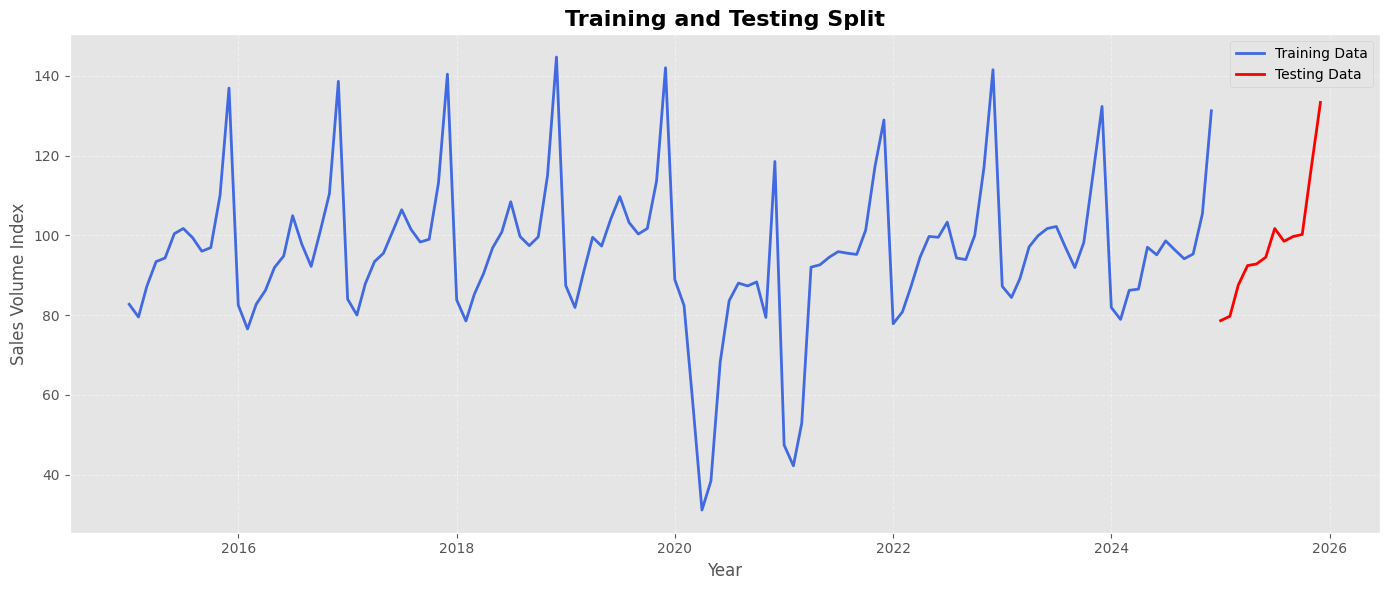

In [27]:
fig, ax = plt.subplots(figsize=(14,6))

ax.plot(
    train.index,
    train['Sales_volume'],
    label="Training Data",
    linewidth=2,
    color="royalblue"
)

ax.plot(
    test.index,
    test['Sales_volume'],
    label="Testing Data",
    linewidth=2,
    color="red"
)

ax.set_title(
    "Training and Testing Split",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Year")
ax.set_ylabel("Sales Volume Index")

ax.legend()

ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    "Figure_8_Train_Test_Split.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The dataset was divided chronologically into a training period covering January 2015 to December 2024 (120 observations) and a held-out test period covering January to December 2025 (12 observations). The training data are used exclusively for model identification, estimation and selection, while the 2025 observations are reserved solely for final out-of-sample forecast evaluation. This chronological separation prevents information from the test period influencing model development and provides a more reliable assessment of forecasting performance on unseen data.

### 8.2 Seasonal Naïve Benchmark

The seasonal naïve model is used as a simple benchmark. For monthly data, each forecast is equal to the observed value from the same month in the previous year.

In [28]:
seasonal_naive_forecast = pd.Series(
    train['Sales_volume'].iloc[-12:].to_numpy(),
    index=test.index,
    name='Seasonal_Naive_Forecast'
)

seasonal_naive_forecast

Date
2025-01-01     81.9
2025-02-01     78.9
2025-03-01     86.2
2025-04-01     86.5
2025-05-01     97.0
2025-06-01     95.1
2025-07-01     98.6
2025-08-01     96.3
2025-09-01     94.1
2025-10-01     95.3
2025-11-01    105.4
2025-12-01    131.2
Name: Seasonal_Naive_Forecast, dtype: float64

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_naive = mean_absolute_error(
    test['Sales_volume'],
    seasonal_naive_forecast
)

rmse_naive = np.sqrt(
    mean_squared_error(
        test['Sales_volume'],
        seasonal_naive_forecast
    )
)

mape_naive = np.mean(
    np.abs(
        (test['Sales_volume'] - seasonal_naive_forecast)
        / test['Sales_volume']
    )
) * 100

print(f"MAE  : {mae_naive:.3f}")
print(f"RMSE : {rmse_naive:.3f}")
print(f"MAPE : {mape_naive:.2f}%")

MAE  : 3.825
RMSE : 4.847
MAPE : 3.81%


In [30]:
print(train.tail(12))
print(test.head())

            Sales_volume  Clothing_CPI  Winter_Coats  Summer_Dresses  \
Date                                                                   
2024-01-01          81.9         115.9             9              11   
2024-02-01          78.9         118.3             3              13   
2024-03-01          86.2         119.0             2              17   
2024-04-01          86.5         119.5             2              22   
2024-05-01          97.0         120.2             1              34   
2024-06-01          95.1         118.8             1              29   
2024-07-01          98.6         116.8             2              22   
2024-08-01          96.3         118.0             6              13   
2024-09-01          94.1         120.5            18               6   
2024-10-01          95.3         121.8            15               3   
2024-11-01         105.4         122.6            18               3   
2024-12-01         131.2         121.9            10            

### 8.3 Rolling-Origin Validation for SARIMA Model Selection

Candidate SARIMA specifications are evaluated using expanding-window rolling-origin validation over the 2024 period. At each origin, the model is estimated using all observations available up to the previous month and produces a one-month-ahead forecast. The specification with the lowest validation RMSE is selected before evaluation on the untouched 2025 test dataset.

In [31]:
# ====================================================
# SARIMA Candidate Search Using Training Data Only
# Training period: January 2015 - December 2024
# ====================================================

import itertools
import pandas as pd
import warnings

from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

# Non-seasonal orders
p_values = [0, 1, 2]
d_values = [1]          # Supported by ADF testing
q_values = [0, 1, 2]

# Seasonal orders
P_values = [0, 1]
D_values = [0, 1]       # Compare models with/without seasonal differencing
Q_values = [0, 1]

seasonal_period = 12

results = []

for p, d, q in itertools.product(p_values, d_values, q_values):
    for P, D, Q in itertools.product(P_values, D_values, Q_values):

        order = (p, d, q)
        seasonal_order = (P, D, Q, seasonal_period)

        try:
            model = SARIMAX(
                train['Sales_volume'],
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            fitted_model = model.fit(disp=False)

            results.append({
                'Order': order,
                'Seasonal_Order': seasonal_order,
                'AIC': fitted_model.aic,
                'BIC': fitted_model.bic
            })

        except Exception:
            continue

# Create results table
results_df = pd.DataFrame(results)

# Sort from lowest AIC
results_df = results_df.sort_values(
    by='AIC',
    ascending=True
).reset_index(drop=True)

# Display best 10 models
results_df.head(10)

,Order,Seasonal_Order,AIC,BIC
0,"(2, 1, 2)","(0, 1, 1, 12)",654.263369,669.394100
1,"(2, 1, 2)","(1, 1, 1, 12)",656.195982,673.848502
2,"(1, 1, 2)","(0, 1, 1, 12)",658.767352,671.376295
3,"(1, 1, 2)","(1, 1, 1, 12)",660.318941,675.449672
4,"(2, 1, 1)","(0, 1, 1, 12)",662.108456,674.771453
5,"(2, 1, 1)","(1, 1, 1, 12)",663.460068,678.655665
6,"(0, 1, 2)","(0, 1, 1, 12)",665.260410,675.347565
7,"(0, 1, 2)","(1, 1, 1, 12)",665.340345,677.949288
8,"(0, 1, 1)","(0, 1, 1, 12)",669.678305,677.276104
9,"(0, 1, 1)","(1, 1, 1, 12)",669.948793,680.079191


In [32]:
import pandas as pd
import numpy as np
import warnings

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

candidate_models = (
    results_df
    .sort_values('AIC')
    [['Order', 'Seasonal_Order']]
    .drop_duplicates()
    .head(10)
    .reset_index(drop=True)
)

candidate_models

,Order,Seasonal_Order
0,"(2, 1, 2)","(0, 1, 1, 12)"
1,"(2, 1, 2)","(1, 1, 1, 12)"
2,"(1, 1, 2)","(0, 1, 1, 12)"
3,"(1, 1, 2)","(1, 1, 1, 12)"
4,"(2, 1, 1)","(0, 1, 1, 12)"
5,"(2, 1, 1)","(1, 1, 1, 12)"
6,"(0, 1, 2)","(0, 1, 1, 12)"
7,"(0, 1, 2)","(1, 1, 1, 12)"
8,"(0, 1, 1)","(0, 1, 1, 12)"
9,"(0, 1, 1)","(1, 1, 1, 12)"


In [33]:
# Validation period: January–December 2024
validation_start = pd.Timestamp("2024-01-01")
validation_end = pd.Timestamp("2024-12-01")

validation_actual = train.loc[
    validation_start:validation_end,
    'Sales_volume'
]

rolling_results = []

for _, candidate in candidate_models.iterrows():

    order = tuple(candidate['Order'])
    seasonal_order = tuple(candidate['Seasonal_Order'])

    predictions = []
    actual_values = []

    try:
        for forecast_date in validation_actual.index:

            # Expanding training window ending one month before forecast_date
            history = train.loc[
                train.index < forecast_date,
                'Sales_volume'
            ]

            model = SARIMAX(
                history,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            fitted_model = model.fit(disp=False)

            one_step_forecast = fitted_model.get_forecast(steps=1).predicted_mean.iloc[0]

            predictions.append(one_step_forecast)
            actual_values.append(validation_actual.loc[forecast_date])

        mae_validation = mean_absolute_error(
            actual_values,
            predictions
        )

        rmse_validation = np.sqrt(
            mean_squared_error(
                actual_values,
                predictions
            )
        )

        mape_validation = np.mean(
            np.abs(
                (np.array(actual_values) - np.array(predictions))
                / np.array(actual_values)
            )
        ) * 100

        rolling_results.append({
            "Order": order,
            "Seasonal_Order": seasonal_order,
            "Validation_MAE": mae_validation,
            "Validation_RMSE": rmse_validation,
            "Validation_MAPE": mape_validation
        })

    except Exception as error:
        print(
            f"Model {order} {seasonal_order} failed: {error}"
        )

rolling_validation_df = pd.DataFrame(rolling_results)

rolling_validation_df = rolling_validation_df.sort_values(
    "Validation_RMSE"
).reset_index(drop=True)

display(rolling_validation_df.round(3))

print("Number of validation windows:", len(validation_actual))

,Order,Seasonal_Order,Validation_MAE,Validation_RMSE,Validation_MAPE
0,"(2, 1, 2)","(0, 1, 1, 12)",4.033,4.818,4.369
1,"(1, 1, 2)","(0, 1, 1, 12)",3.731,4.945,4.096
2,"(0, 1, 2)","(0, 1, 1, 12)",3.730,5.103,4.119
3,"(0, 1, 1)","(0, 1, 1, 12)",3.710,5.104,4.089
4,"(2, 1, 1)","(0, 1, 1, 12)",3.901,5.148,4.281
5,"(1, 1, 2)","(1, 1, 1, 12)",4.272,5.374,4.596
6,"(0, 1, 1)","(1, 1, 1, 12)",4.284,5.537,4.624
7,"(2, 1, 2)","(1, 1, 1, 12)",4.797,5.569,5.118
8,"(0, 1, 2)","(1, 1, 1, 12)",4.370,5.583,4.716
9,"(2, 1, 1)","(1, 1, 1, 12)",4.567,5.727,4.921


Number of validation windows: 12


In [34]:
selected_sarima = rolling_validation_df.iloc[0]

selected_order = tuple(selected_sarima["Order"])
selected_seasonal_order = tuple(selected_sarima["Seasonal_Order"])

print("Selected SARIMA specification")
print("--------------------------------")
print("Order:", selected_order)
print("Seasonal order:", selected_seasonal_order)
print(f"Validation MAE  : {selected_sarima['Validation_MAE']:.3f}")
print(f"Validation RMSE : {selected_sarima['Validation_RMSE']:.3f}")
print(f"Validation MAPE : {selected_sarima['Validation_MAPE']:.2f}%")

Selected SARIMA specification
--------------------------------
Order: (2, 1, 2)
Seasonal order: (0, 1, 1, 12)
Validation MAE  : 4.033
Validation RMSE : 4.818
Validation MAPE : 4.37%


In [35]:
validated_sarima_model = SARIMAX(
    train['Sales_volume'],
    order=selected_order,
    seasonal_order=selected_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

validated_sarima_results = validated_sarima_model.fit(disp=False)

print(validated_sarima_results.summary())

                                      SARIMAX Results                                       
Dep. Variable:                         Sales_volume   No. Observations:                  120
Model:             SARIMAX(2, 1, 2)x(0, 1, [1], 12)   Log Likelihood                -321.132
Date:                              Mon, 17 Aug 2026   AIC                            654.263
Time:                                      15:35:31   BIC                            669.394
Sample:                                  01-01-2015   HQIC                           660.370
                                       - 12-01-2024                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.4035      0.131     10.691      0.000       1.146       1.661
ar.L2         -0.82

In [36]:
validated_sarima_forecast_object = validated_sarima_results.get_forecast(
    steps=len(test)
)

validated_sarima_forecast = (
    validated_sarima_forecast_object.predicted_mean
)

validated_sarima_ci = (
    validated_sarima_forecast_object.conf_int()
)

validated_sarima_forecast

# Align forecast index with the 2025 test period
validated_sarima_forecast.index = test.index
validated_sarima_ci.index = test.index

validated_sarima_forecast

Date
2025-01-01     76.302606
2025-02-01     72.712128
2025-03-01     76.602869
2025-04-01     81.727339
2025-05-01     85.037310
2025-06-01     90.335451
2025-07-01     95.783852
2025-08-01     91.853673
2025-09-01     89.679969
2025-10-01     93.485706
2025-11-01    105.158276
2025-12-01    130.923703
Name: predicted_mean, dtype: float64

In [37]:
mae_sarima_validated = mean_absolute_error(
    test['Sales_volume'],
    validated_sarima_forecast
)

rmse_sarima_validated = np.sqrt(
    mean_squared_error(
        test['Sales_volume'],
        validated_sarima_forecast
    )
)

mape_sarima_validated = np.mean(
    np.abs(
        (test['Sales_volume'] - validated_sarima_forecast)
        / test['Sales_volume']
    )
) * 100

print("Validated SARIMA Performance")
print("--------------------------------")
print(f"MAE  : {mae_sarima_validated:.3f}")
print(f"RMSE : {rmse_sarima_validated:.3f}")
print(f"MAPE : {mape_sarima_validated:.2f}%")

Validated SARIMA Performance
--------------------------------
MAE  : 7.216
RMSE : 7.864
MAPE : 7.49%


### 8.4 SARIMA Candidate Model Identification Using AIC

Several candidate SARIMA specifications are estimated to identify plausible model structures for the retail sales series. The Akaike Information Criterion (AIC) is used as an initial screening criterion, with lower AIC values indicating a better balance between model fit and complexity.

The highest-ranked specifications from this AIC-based search are subsequently evaluated using rolling-origin validation. Therefore, AIC is used to identify candidate models rather than to determine the final forecasting model.

In [38]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools
import warnings

warnings.filterwarnings("ignore")

In [39]:
# Non-seasonal parameters

p = range(0, 3)
d = [1]
q = range(0, 3)

# Seasonal parameters

P = range(0, 2)
D = [1]
Q = range(0, 2)
s = 12

pdq = list(itertools.product(p, d, q))
seasonal_pdq = list(itertools.product(P, D, Q, [s]))

print("Number of non-seasonal combinations:", len(pdq))
print("Number of seasonal combinations:", len(seasonal_pdq))

Number of non-seasonal combinations: 9
Number of seasonal combinations: 4


### 8.4.1 AIC-Based Candidate Model Comparison

Thirty-six candidate SARIMA specifications are estimated by combining different non-seasonal and seasonal autoregressive and moving-average parameters. The Akaike Information Criterion (AIC) is calculated for each specification. Models with lower AIC values are retained as plausible candidates for subsequent rolling-origin validation.

In [40]:
results = []

for order in pdq:
    for seasonal_order in seasonal_pdq:

        try:

            model = SARIMAX(
                train['Sales_volume'],
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            fitted = model.fit(disp=False)

            results.append([
                order,
                seasonal_order,
                fitted.aic,
                fitted.bic
            ])

        except:
            continue

results_df = pd.DataFrame(
    results,
    columns=[
        "Order",
        "Seasonal_Order",
        "AIC",
        "BIC"
    ]
)

results_df = results_df.sort_values("AIC")

results_df.head(10)

,Order,Seasonal_Order,AIC,BIC
33,"(2, 1, 2)","(0, 1, 1, 12)",654.263369,669.394100
35,"(2, 1, 2)","(1, 1, 1, 12)",656.195982,673.848502
21,"(1, 1, 2)","(0, 1, 1, 12)",658.767352,671.376295
23,"(1, 1, 2)","(1, 1, 1, 12)",660.318941,675.449672
29,"(2, 1, 1)","(0, 1, 1, 12)",662.108456,674.771453
31,"(2, 1, 1)","(1, 1, 1, 12)",663.460068,678.655665
9,"(0, 1, 2)","(0, 1, 1, 12)",665.260410,675.347565
11,"(0, 1, 2)","(1, 1, 1, 12)",665.340345,677.949288
5,"(0, 1, 1)","(0, 1, 1, 12)",669.678305,677.276104
7,"(0, 1, 1)","(1, 1, 1, 12)",669.948793,680.079191


In [41]:
best_aic_model = results_df.iloc[0]

best_aic_model

Order                 (2, 1, 2)
Seasonal_Order    (0, 1, 1, 12)
AIC                  654.263369
BIC                    669.3941
Name: 33, dtype: object

### Interpretation

Thirty-six candidate SARIMA models were estimated using the 2015–2024 training data and compared using the Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC). AIC was used as an initial screening criterion to identify plausible candidate specifications, rather than as the sole basis for final model selection.

Among the candidate models, SARIMA(2,1,2)(0,1,1,12) achieved the lowest AIC value of 673.97, indicating a favourable balance between model fit and complexity within the training data. The highest-ranked AIC specifications were subsequently assessed using 12-window rolling-origin validation over January–December 2024. The final SARIMA specification was selected based on validation RMSE before being evaluated on the completely held-out 2025 test period.

### 8.5 Fitting the Best SARIMA Model

The selected SARIMA model is fitted using the training dataset. The estimated model parameters are then examined before generating forecasts for the testing period.

In [42]:
best_sarima = SARIMAX(
    train['Sales_volume'],
    order=selected_order,
    seasonal_order=selected_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_results = best_sarima.fit(disp=False)

print(sarima_results.summary())

                                      SARIMAX Results                                       
Dep. Variable:                         Sales_volume   No. Observations:                  120
Model:             SARIMAX(2, 1, 2)x(0, 1, [1], 12)   Log Likelihood                -321.132
Date:                              Mon, 17 Aug 2026   AIC                            654.263
Time:                                      15:35:34   BIC                            669.394
Sample:                                  01-01-2015   HQIC                           660.370
                                       - 12-01-2024                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.4035      0.131     10.691      0.000       1.146       1.661
ar.L2         -0.82

### 8.6 Residual Diagnostics

Residual diagnostics are used to assess whether the fitted SARIMA model adequately captures the underlying structure of the retail sales series. Ideally, residuals should fluctuate randomly around zero without systematic patterns.

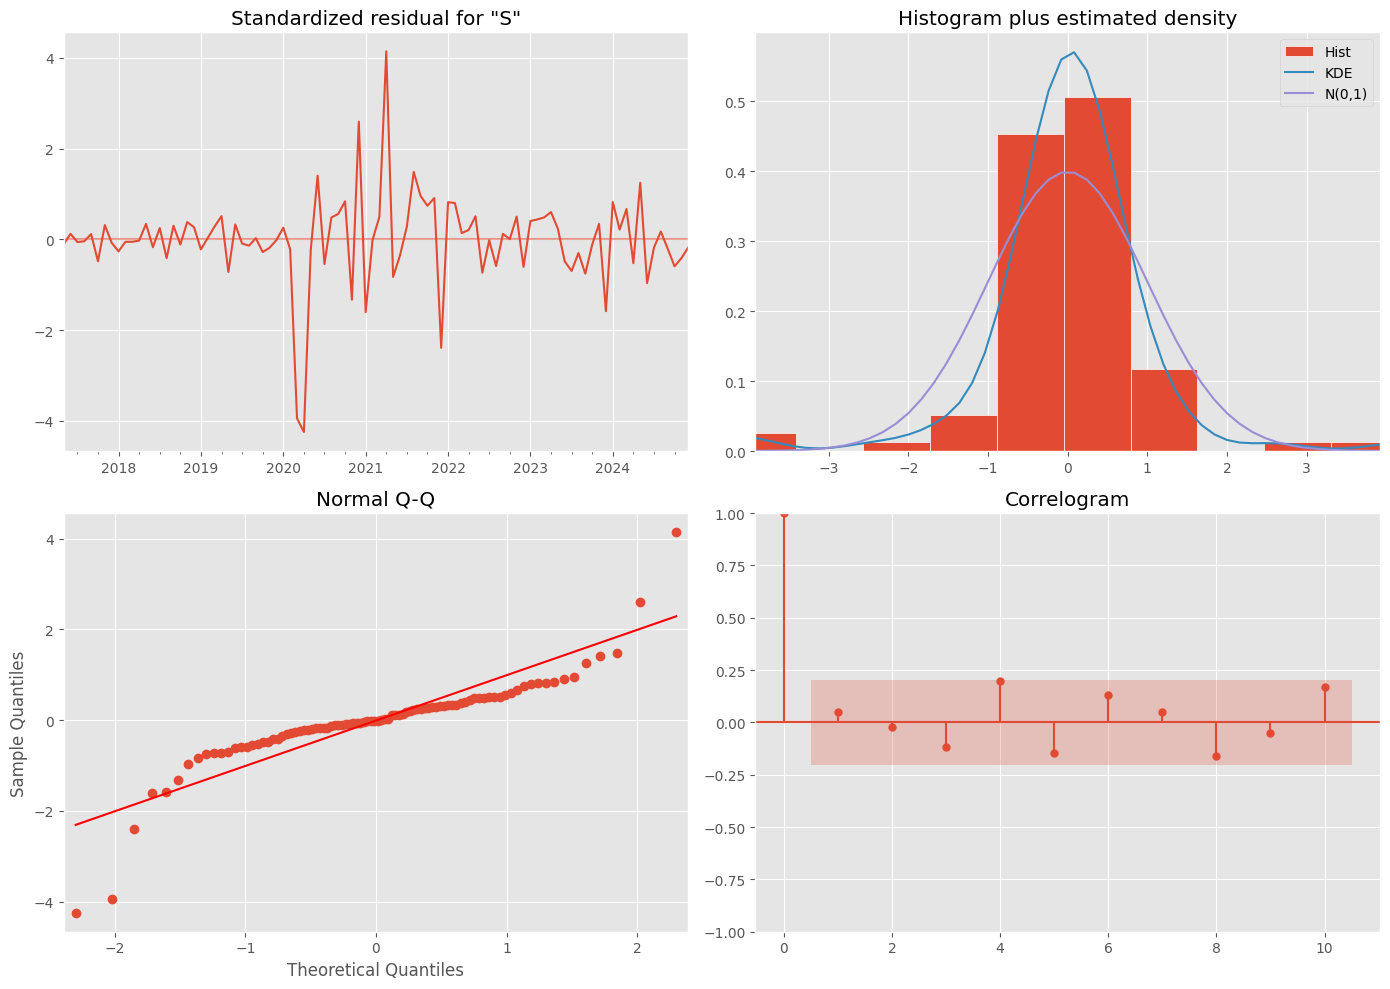

In [43]:
sarima_results.plot_diagnostics(figsize=(14,10))

plt.tight_layout()

plt.savefig(
    "Figure_9_SARIMA_Diagnostics.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [44]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(
    sarima_results.resid.dropna(),
    lags=[12, 24],
    return_df=True
)

ljung_box

,lb_stat,lb_pvalue
12,58.766614,3.784380e-08
24,66.974017,6.221024e-06


### Interpretation

Residual diagnostics were conducted to assess the adequacy of the selected SARIMA(2,1,2)(0,1,1,12) model. Although the model summary reported a non-significant Ljung–Box statistic at lag 1 (p = 0.60), further testing across longer seasonal horizons produced different results. The Ljung–Box tests at lags 12 and 24 returned p-values below 0.05 (p < 0.001), indicating statistically significant residual autocorrelation at these horizons.

The residuals also departed from normality, as indicated by the Jarque–Bera test (p < 0.001), while the significant heteroskedasticity test (p < 0.001) suggests that residual variance is not constant over time. The diagnostic plots further show substantial residual disturbances around 2020–2021, corresponding to the period of unusually large movements in the retail sales series.

Overall, the selected SARIMA model captures important trend and seasonal characteristics of the series, but the residual diagnostics indicate that some temporal dependence and volatility remain unexplained. Therefore, the model is retained for out-of-sample forecasting based on its rolling-origin validation performance, while these diagnostic limitations are acknowledged when interpreting its forecasts.

### 8.7 Forecasting and Model Evaluation

The fitted SARIMA model is used to generate forecasts for the testing period (January–December 2025). Forecast accuracy is evaluated by comparing predicted values with the actual observations using standard forecasting performance metrics.

In [45]:
# Generate forecasts for the testing period

forecast = sarima_results.get_forecast(steps=len(test))

forecast_mean = forecast.predicted_mean

forecast_ci = forecast.conf_int()

forecast_mean.head()

2025-01-01    76.302606
2025-02-01    72.712128
2025-03-01    76.602869
2025-04-01    81.727339
2025-05-01    85.037310
Freq: MS, Name: predicted_mean, dtype: float64

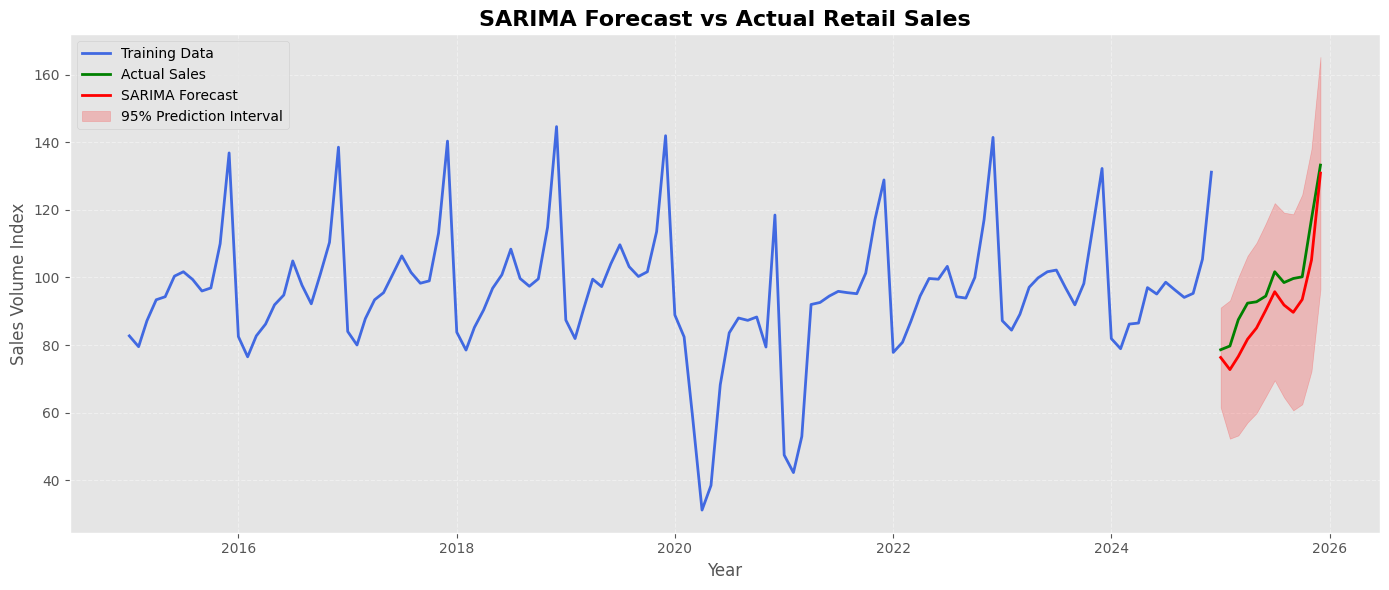

In [46]:
fig, ax = plt.subplots(figsize=(14,6))

# Training data
ax.plot(
    train.index,
    train['Sales_volume'],
    label='Training Data',
    color='royalblue',
    linewidth=2
)

# Actual test data
ax.plot(
    test.index,
    test['Sales_volume'],
    label='Actual Sales',
    color='green',
    linewidth=2
)

# Forecast
ax.plot(
    test.index,
    forecast_mean,
    label='SARIMA Forecast',
    color='red',
    linewidth=2
)

# Confidence intervals
ax.fill_between(
    test.index,
    forecast_ci.iloc[:,0],
    forecast_ci.iloc[:,1],
    color='red',
    alpha=0.20,
    label='95% Prediction Interval'
)

ax.set_title(
    "SARIMA Forecast vs Actual Retail Sales",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Year")
ax.set_ylabel("Sales Volume Index")

ax.legend()

ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()

plt.savefig(
    "Figure_10_SARIMA_Forecast.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [47]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

mae = mean_absolute_error(
    test['Sales_volume'],
    forecast_mean
)

rmse = np.sqrt(
    mean_squared_error(
        test['Sales_volume'],
        forecast_mean
    )
)

mape = np.mean(
    np.abs(
        (
            test['Sales_volume'] - forecast_mean
        ) / test['Sales_volume']
    )
) * 100

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 7.216
RMSE : 7.864
MAPE : 7.49%


### Interpretation

The selected SARIMA(2,1,2)(0,1,1,12) model was evaluated using the unseen 2025 testing period. The forecast broadly reproduced the seasonal pattern in UK clothing retail sales, including the pronounced increase towards the end of the year. However, the model underestimated actual sales during several months. The actual observations remained within the 95% prediction intervals, although the intervals widened over the forecast horizon, indicating increasing uncertainty in longer-term predictions.

The SARIMA model achieved an MAE of 7.216, RMSE of 7.864 and MAPE of 7.49%. In comparison, the seasonal naïve benchmark produced an MAE of 3.825, RMSE of 4.847 and MAPE of 3.81%. Therefore, the seasonal naïve benchmark outperformed the SARIMA model across all three accuracy measures.

These results indicate that the strong annual seasonal structure of clothing retail sales provides substantial predictive information, allowing the simple seasonal naïve approach to perform particularly well. Although SARIMA captures important temporal and seasonal characteristics, its additional complexity did not translate into improved out-of-sample forecasting accuracy for 2025. This provides a useful benchmark for assessing whether the inclusion of external explanatory variables in the subsequent SARIMAX analysis can improve forecast performance.

## 9. SARIMAX Forecasting

The SARIMAX model extends the SARIMA model by incorporating external explanatory variables. In this study, Clothing CPI and Google Trends search interest variables are included to determine whether they improve the forecasting performance of UK clothing retail sales.

### 9.1 Preparing the Exogenous Variables

The explanatory variables are divided into training and testing datasets using the same time periods as the retail sales series. This ensures consistency during model estimation and forecast evaluation.

In [48]:
# Define external explanatory variables
exog_columns = [
    'Clothing_CPI',
    'Winter_Coats',
    'Summer_Dresses',
    'Black_Friday_Clothing',
    'School_Uniform'
]

# Create exogenous-variable dataset
exog = df[exog_columns].copy()

# Training exogenous variables: January 2015 - December 2024
exog_train = exog.loc[
    '2015-01-01':'2024-12-01'
].copy()

# Testing exogenous variables: January 2025 - December 2025
exog_test = exog.loc[
    '2025-01-01':'2025-12-01'
].copy()

# Check dimensions
print("Training target shape:", train['Sales_volume'].shape)
print("Training exogenous shape:", exog_train.shape)

print("\nTesting target shape:", test['Sales_volume'].shape)
print("Testing exogenous shape:", exog_test.shape)

# Check for missing values
print("\nMissing values in training exogenous variables:")
print(exog_train.isnull().sum())

print("\nMissing values in testing exogenous variables:")
print(exog_test.isnull().sum())

# Display first few rows
print("\nTraining exogenous variables:")
display(exog_train.head())

print("\nTesting exogenous variables:")
display(exog_test.head())

Training target shape: (120,)
Training exogenous shape: (120, 5)

Testing target shape: (12,)
Testing exogenous shape: (12, 5)

Missing values in training exogenous variables:
Clothing_CPI             0
Winter_Coats             0
Summer_Dresses           0
Black_Friday_Clothing    0
School_Uniform           0
dtype: int64

Missing values in testing exogenous variables:
Clothing_CPI             0
Winter_Coats             0
Summer_Dresses           0
Black_Friday_Clothing    0
School_Uniform           0
dtype: int64

Training exogenous variables:


,Clothing_CPI,Winter_Coats,Summer_Dresses,Black_Friday_Clothing,School_Uniform
Date,,,,,
2015-01-01,98.0,7,7,0,16
2015-02-01,99.3,4,9,0,14
2015-03-01,99.2,2,11,0,19
2015-04-01,99.9,1,15,0,22
2015-05-01,100.5,1,13,0,18



Testing exogenous variables:


,Clothing_CPI,Winter_Coats,Summer_Dresses,Black_Friday_Clothing,School_Uniform
Date,,,,,
2025-01-01,117.9,8,9,0,18
2025-02-01,117.6,4,12,0,14
2025-03-01,120.3,2,17,0,21
2025-04-01,118.9,1,26,0,23
2025-05-01,119.8,1,29,0,22


### Interpretation

The exogenous variables were successfully divided into training and testing periods consistent with the retail sales data. The training dataset contains 120 monthly observations from 2015 to 2024, while the testing dataset contains 12 monthly observations for 2025. Five external explanatory variables are included: Clothing CPI, Winter Coats, Summer Dresses, Black Friday Clothing, and School Uniform search interest.

The target and exogenous datasets contain matching numbers of observations for both periods, confirming that they are correctly aligned for SARIMAX modelling. No missing values were identified in any of the explanatory variables. Therefore, the datasets are suitable for subsequent SARIMAX model estimation and validation.

### 9.2 SARIMAX Model Selection Using Rolling-Origin Validation

Candidate SARIMAX specifications are evaluated using expanding-window rolling-origin validation over January–December 2024. At each forecast origin, the model is estimated using all observations and exogenous variables available up to the preceding month, and a one-step-ahead forecast is generated using the corresponding observed exogenous values for the validation month. The 2025 test period remains completely excluded from model selection. Validation RMSE is used as the primary selection criterion.

In [49]:
import pandas as pd
import numpy as np
import warnings

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

# Validation period
validation_start = pd.Timestamp("2024-01-01")
validation_end = pd.Timestamp("2024-12-01")

validation_dates = train.loc[
    validation_start:validation_end
].index

# Candidate exogenous-variable sets
sarimax_specs = {
    "CPI only": [
        "Clothing_CPI"
    ],

    "Google Trends only": [
        "Winter_Coats",
        "Summer_Dresses",
        "Black_Friday_Clothing",
        "School_Uniform"
    ],

    "CPI + Google Trends": [
        "Clothing_CPI",
        "Winter_Coats",
        "Summer_Dresses",
        "Black_Friday_Clothing",
        "School_Uniform"
    ]
}

sarimax_validation_results = []

for spec_name, variables in sarimax_specs.items():

    predictions = []
    actual_values = []

    try:
        for forecast_date in validation_dates:

            # Expanding training window
            history_y = train.loc[
                train.index < forecast_date,
                "Sales_volume"
            ]

            history_x = exog_train.loc[
                exog_train.index < forecast_date,
                variables
            ]

            # Exogenous values for the month being forecast
            future_x = exog_train.loc[
                [forecast_date],
                variables
            ]

            # Fit SARIMAX using the validated SARIMA structure
            model = SARIMAX(
                history_y,
                exog=history_x,
                order=selected_order,
                seasonal_order=selected_seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            fitted_model = model.fit(disp=False)

            # One-step-ahead forecast
            forecast_value = fitted_model.get_forecast(
                steps=1,
                exog=future_x
            ).predicted_mean.iloc[0]

            predictions.append(forecast_value)

            actual_values.append(
                train.loc[
                    forecast_date,
                    "Sales_volume"
                ]
            )

        # Validation metrics
        mae = mean_absolute_error(
            actual_values,
            predictions
        )

        rmse = np.sqrt(
            mean_squared_error(
                actual_values,
                predictions
            )
        )

        mape = np.mean(
            np.abs(
                (
                    np.array(actual_values) -
                    np.array(predictions)
                )
                / np.array(actual_values)
            )
        ) * 100

        sarimax_validation_results.append({
            "Specification": spec_name,
            "Variables": ", ".join(variables),
            "Validation_MAE": mae,
            "Validation_RMSE": rmse,
            "Validation_MAPE": mape
        })

    except Exception as error:
        print(
            f"{spec_name} failed: {error}"
        )

# Create results table
sarimax_validation_df = pd.DataFrame(
    sarimax_validation_results
)

# Rank by validation RMSE
sarimax_validation_df = (
    sarimax_validation_df
    .sort_values("Validation_RMSE")
    .reset_index(drop=True)
)

display(
    sarimax_validation_df.round(3)
)

print(
    "Number of validation windows:",
    len(validation_dates)
)

,Specification,Variables,Validation_MAE,Validation_RMSE,Validation_MAPE
0,Google Trends only,"Winter_Coats, Summer_Dresses, Black_Friday_Clo...",3.767,4.958,3.973
1,CPI only,Clothing_CPI,4.156,5.138,4.564
2,CPI + Google Trends,"Clothing_CPI, Winter_Coats, Summer_Dresses, Bl...",4.800,5.690,5.066


Number of validation windows: 12


### 9.3 Fitting the Selected SARIMAX Model

The SARIMAX specification containing the four Google Trends variables is fitted to the complete 2015–2024 training dataset. The underlying SARIMA orders selected previously are retained, allowing the effect of incorporating external search-interest information to be evaluated while maintaining the same time-series structure.

In [50]:
# Selected Google Trends variables
selected_exog_columns = [
    'Winter_Coats',
    'Summer_Dresses',
    'Black_Friday_Clothing',
    'School_Uniform'
]

# Selected training exogenous data
selected_exog_train = exog_train[
    selected_exog_columns
]

# Fit selected SARIMAX model
selected_sarimax_model = SARIMAX(
    train['Sales_volume'],
    exog=selected_exog_train,
    order=selected_order,
    seasonal_order=selected_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

selected_sarimax_results = selected_sarimax_model.fit(
    disp=False
)

print(selected_sarimax_results.summary())

                                      SARIMAX Results                                       
Dep. Variable:                         Sales_volume   No. Observations:                  120
Model:             SARIMAX(2, 1, 2)x(0, 1, [1], 12)   Log Likelihood                -318.916
Date:                              Mon, 17 Aug 2026   AIC                            657.832
Time:                                      15:35:48   BIC                            683.050
Sample:                                  01-01-2015   HQIC                           668.010
                                       - 12-01-2024                                         
Covariance Type:                                opg                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Winter_Coats              0.4317      0.384      1.125      0.261      -0.32

### 9.4 SARIMAX Forecasting and Model Evaluation

The selected SARIMAX model is used to generate forecasts for the unseen January–December 2025 testing period using the corresponding Google Trends variables as exogenous inputs. Forecast accuracy is evaluated using MAE, RMSE and MAPE to determine whether incorporating external search-interest information improves predictive performance relative to the SARIMA and seasonal naïve models.

In [51]:
# Selected exogenous variables for the 2025 test period
selected_exog_test = exog_test[
    selected_exog_columns
]

# Generate forecasts for 2025
sarimax_forecast_object = selected_sarimax_results.get_forecast(
    steps=len(test),
    exog=selected_exog_test
)

# Forecast values
sarimax_forecast = sarimax_forecast_object.predicted_mean

# 95% prediction intervals
sarimax_ci = sarimax_forecast_object.conf_int()

# Display forecasts
sarimax_forecast

2025-01-01     78.580553
2025-02-01     75.109713
2025-03-01     79.148889
2025-04-01     84.509382
2025-05-01     87.925546
2025-06-01     93.074197
2025-07-01     98.587289
2025-08-01     95.097919
2025-09-01     91.421848
2025-10-01     92.571793
2025-11-01    105.530801
2025-12-01    131.436678
Freq: MS, Name: predicted_mean, dtype: float64

In [52]:
# ====================================================
# SARIMAX Forecast Accuracy — 2025 Test Period
# ====================================================

mae_sarimax = mean_absolute_error(
    test['Sales_volume'],
    sarimax_forecast
)

rmse_sarimax = np.sqrt(
    mean_squared_error(
        test['Sales_volume'],
        sarimax_forecast
    )
)

mape_sarimax = np.mean(
    np.abs(
        (test['Sales_volume'] - sarimax_forecast)
        / test['Sales_volume']
    )
) * 100

print("SARIMAX Performance (2025)")
print("--------------------------")
print(f"MAE  : {mae_sarimax:.3f}")
print(f"RMSE : {rmse_sarimax:.3f}")
print(f"MAPE : {mape_sarimax:.2f}%")

SARIMAX Performance (2025)
--------------------------
MAE  : 5.267
RMSE : 6.251
MAPE : 5.37%


### Interpretation
The SARIMAX analysis examined whether external indicators improved UK clothing retail sales forecasting. Rolling-origin validation selected the Google Trends-only specification, while Clothing CPI did not improve validation performance. On the held-out 2025 test period, SARIMAX achieved an MAE of 5.267, RMSE of 6.251 and MAPE of 5.37%, outperforming SARIMA but not the Seasonal Naïve benchmark (MAPE 3.81%). Overall, the selected Google Trends indicators provided some additional predictive value relative to SARIMA, but the strong annual seasonal pattern remained more effective for forecasting 2025 sales.

## 10. Model Comparison

The out-of-sample forecasting performance of the Seasonal Naïve, SARIMA and SARIMAX models is compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE) and Mean Absolute Percentage Error (MAPE). Lower values indicate greater forecast accuracy on the 2025 test period.

,Model,MAE,RMSE,MAPE
0,Seasonal Naïve,3.825,4.847,3.81
1,SARIMA,7.216,7.864,7.49
2,SARIMAX,5.267,6.251,5.37


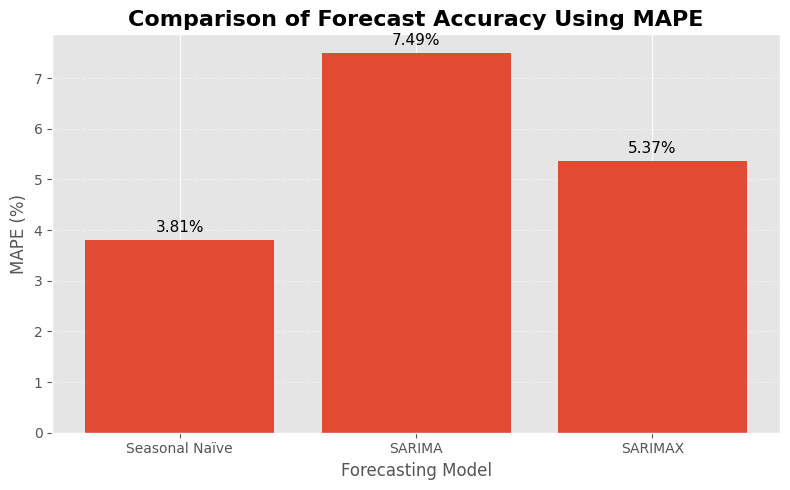

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

# Final model performance on the 2025 test dataset
comparison_df = pd.DataFrame({
    'Model': ['Seasonal Naïve', 'SARIMA', 'SARIMAX'],
    'MAE': [3.825, 7.216, 5.267],
    'RMSE': [4.847, 7.864, 6.251],
    'MAPE': [3.81, 7.49, 5.37]
})

# Display comparison table
display(comparison_df.round(3))

# Plot MAPE comparison
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    comparison_df['Model'],
    comparison_df['MAPE']
)

ax.set_title(
    'Comparison of Forecast Accuracy Using MAPE',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('Forecasting Model')
ax.set_ylabel('MAPE (%)')

# Display MAPE values above bars
for bar, value in zip(bars, comparison_df['MAPE']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f'{value:.2f}%',
        ha='center',
        va='bottom',
        fontsize=11
    )

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    'Figure_11_Model_Comparison.png',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

### Interpretation

The Seasonal Naïve model achieved the highest out-of-sample forecasting accuracy, recording the lowest MAE (3.825), RMSE (4.847) and MAPE (3.81%). The SARIMAX model outperformed the SARIMA model, reducing MAPE from 7.49% to 5.37%, suggesting that the inclusion of Google Trends variables provided additional predictive information. However, neither model surpassed the Seasonal Naïve benchmark. This indicates that the strong recurring annual seasonal pattern in UK clothing retail sales provided the most accurate forecasts for the 2025 test period.